# Daten einlesen und vorbereiten

In [37]:
import pandas as pd
from pycparser.plyparser import Coord

#from Scripts.Live_Session_Week1_1 import df
#from rich.columns import Columns

path_processed_data = '../Data/Processed/'
time_series_holidays = pd.read_csv(path_processed_data + 'timeseries_holidays.csv')

# Spalte 1 "Unnamed: 0" entfernen. Ist vermutlich irgendwann aus Index hervorgegangen
time_series_holidays = time_series_holidays.drop(columns="Unnamed: 0")

# Format der Spalte Datum richten
time_series_holidays['date'] = pd.to_datetime(time_series_holidays['date'])

time_series_holidays.head()

,date,unit_sales,national_holiday,day_type,day_category
0,2013-01-02,582.0,no,weekday,weekday
1,2013-01-03,310.0,no,weekday,weekday
2,2013-01-04,338.0,no,weekday,weekday
3,2013-01-05,654.0,yes!,weekend,holiday (weekend)
4,2013-01-06,979.0,no,weekend,weekend


# Feature Engineering
## Neue Features ausdenken

In [38]:
time_series_added_features = time_series_holidays.copy()

print(time_series_added_features["national_holiday"].unique())
print()
print(time_series_added_features["day_type"].unique())
print()
print(time_series_added_features["day_category"].unique())

<StringArray>
['no', 'yes!']
Length: 2, dtype: str

<StringArray>
['weekday', 'weekend']
Length: 2, dtype: str

<StringArray>
['weekday', 'holiday (weekend)', 'weekend', 'holiday (weekday)']
Length: 4, dtype: str


In [39]:
# Bestehende Säulen ändern
# (a) Statt day_type (weekend or weekday) hat man lieber Nullen und Einsen -> neue Säule "is_weekday" erstellen und "day_type" löschen
time_series_added_features['is_weekday'] = (time_series_added_features['day_type'] == 'weekday').astype(int)
time_series_added_features = time_series_added_features.drop(columns='day_type')

# (b) Ich weiß ob Wochenende ist oder nicht durch (a). Nun will ich wissen ob Holiday ist oder nicht. Ich brauche nicht beides zusammen in einer Säule -> werfe Säule "day_category" raus
time_series_added_features['is_holiday'] = time_series_added_features['day_category'].str.contains('holiday').astype(int)
time_series_added_features = time_series_added_features.drop(columns='day_category')

# (c) Säule "national_holiday" überflüssig, da alle holidays = national holidays
time_series_added_features = time_series_added_features.drop(columns='national_holiday')

time_series_added_features.head(4)

,date,unit_sales,is_weekday,is_holiday
0,2013-01-02,582.0,1,0
1,2013-01-03,310.0,1,0
2,2013-01-04,338.0,1,0
3,2013-01-05,654.0,0,1


In [40]:
# (1) Zeitbasierte Features
time_series_added_features['dayofweek']    = time_series_added_features['date'].dt.dayofweek
time_series_added_features['dayofmonth']   = time_series_added_features['date'].dt.day
time_series_added_features['dayofyear']    = time_series_added_features['date'].dt.dayofyear
time_series_added_features['weekofyear']   = time_series_added_features['date'].dt.isocalendar().week.astype(int)
time_series_added_features['month']        = time_series_added_features['date'].dt.month
time_series_added_features['quarter']      = time_series_added_features['date'].dt.quarter  # quarter teilt das Jahr in 4 Abschnitte
time_series_added_features['is_weekend']   = time_series_added_features['date'].dt.dayofweek >= 5

# (2) Lag Features
time_series_added_features['lag_7']  = time_series_added_features['unit_sales'].shift(7)
time_series_added_features['lag_14'] = time_series_added_features['unit_sales'].shift(14)
time_series_added_features['lag_21'] = time_series_added_features['unit_sales'].shift(21)
time_series_added_features['lag_28'] = time_series_added_features['unit_sales'].shift(28)

# (3) Rolling Features
# (3a) Rolling Mean
## Bsp: Rolling Mean 7 mit Shift 1 beantwortet die Frage: Wie viel wurde im Mittel in den letzten 7 Tagen bis inkl. gestern verkauft?
time_series_added_features['rolling_mean_7']  = time_series_added_features['unit_sales'].shift(1).rolling(7).mean()
time_series_added_features['rolling_mean_14'] = time_series_added_features['unit_sales'].shift(1).rolling(14).mean()
time_series_added_features['rolling_mean_21'] = time_series_added_features['unit_sales'].shift(1).rolling(21).mean()
time_series_added_features['rolling_mean_28'] = time_series_added_features['unit_sales'].shift(1).rolling(28).mean()

# (3b) Rolling Std
time_series_added_features['rolling_std_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).std()
time_series_added_features['rolling_std_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).std()
time_series_added_features['rolling_std_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).std()
time_series_added_features['rolling_std_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).std()

# (3c) Rolling Max
time_series_added_features['rolling_max_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).max()
time_series_added_features['rolling_max_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).max()
time_series_added_features['rolling_max_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).max()
time_series_added_features['rolling_max_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).max()

# (3d) Rolling Min
time_series_added_features['rolling_min_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).min()
time_series_added_features['rolling_min_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).min()
time_series_added_features['rolling_min_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).min()
time_series_added_features['rolling_min_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).min()

# NaNs entfernen
# time_series_added_features = time_series_added_features.dropna()

time_series_added_features.head(4)

,date,unit_sales,is_weekday,is_holiday,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,...,rolling_std_21,rolling_std_28,rolling_max_7,rolling_max_14,rolling_max_21,rolling_max_28,rolling_min_7,rolling_min_14,rolling_min_21,rolling_min_28
0,2013-01-02,582.0,1,0,2,2,2,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-03,310.0,1,0,3,3,3,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-04,338.0,1,0,4,4,4,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-05,654.0,0,1,5,5,5,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Colinearität?

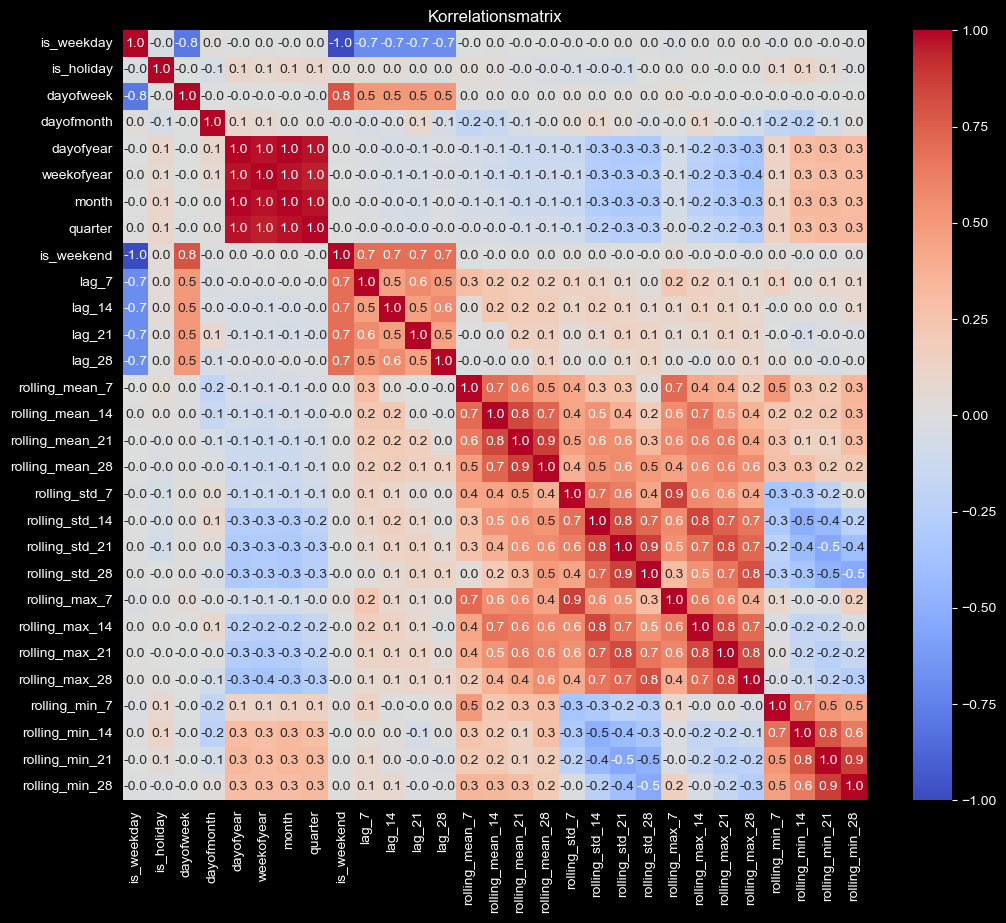

,is_weekday,is_holiday,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,is_weekend,lag_7,...,rolling_std_21,rolling_std_28,rolling_max_7,rolling_max_14,rolling_max_21,rolling_max_28,rolling_min_7,rolling_min_14,rolling_min_21,rolling_min_28
is_weekday,1.000000,-0.046333,-0.790395,0.018385,-0.002062,0.003100,-0.003627,0.007413,-1.000000,-0.689565,...,0.001088,0.001427,-0.035160,0.006343,0.005860,0.008261,-0.026036,0.000681,-0.006348,-0.008510
is_holiday,-0.046333,1.000000,-0.005442,-0.050756,0.093275,0.064335,0.097600,0.091710,0.046333,0.032824,...,-0.080993,-0.004982,0.001860,0.011572,-0.000970,0.014606,0.084855,0.112958,0.053012,-0.022051
dayofweek,-0.790395,-0.005442,1.000000,-0.007093,-0.005881,-0.005824,-0.005298,-0.013616,0.790395,0.505530,...,0.009272,0.008516,0.040501,-0.003842,-0.002264,-0.004584,-0.001088,-0.009851,-0.002665,-0.000642
dayofmonth,0.018385,-0.050756,-0.007093,1.000000,0.088412,0.064172,0.008725,0.011107,-0.018385,-0.043515,...,0.025214,-0.044078,-0.000313,0.085046,-0.001078,-0.082930,-0.193883,-0.221639,-0.083431,0.021354
dayofyear,-0.002062,0.093275,-0.005881,0.088412,1.000000,0.975831,0.996792,0.970963,0.002062,-0.018548,...,-0.301661,-0.304974,-0.083683,-0.222820,-0.275591,-0.343968,0.131687,0.307520,0.326202,0.311991
weekofyear,0.003100,0.064335,-0.005824,0.064172,0.975831,1.000000,0.974511,0.952166,-0.003100,-0.024792,...,-0.291463,-0.286477,-0.066369,-0.240731,-0.290328,-0.356066,0.115910,0.289667,0.308491,0.305727
month,-0.003627,0.097600,-0.005298,0.008725,0.996792,0.974511,1.000000,0.973534,0.003627,-0.015207,...,-0.307395,-0.306354,-0.084955,-0.232053,-0.279007,-0.342338,0.147893,0.326411,0.334400,0.312448
quarter,0.007413,0.091710,-0.013616,0.011107,0.970963,0.952166,0.973534,1.000000,-0.007413,-0.014920,...,-0.250580,-0.257632,-0.042548,-0.160246,-0.204814,-0.267506,0.133290,0.293535,0.319759,0.318298
is_weekend,-1.000000,0.046333,0.790395,-0.018385,0.002062,-0.003100,0.003627,-0.007413,1.000000,0.689565,...,-0.001088,-0.001427,0.035160,-0.006343,-0.005860,-0.008261,0.026036,-0.000681,0.006348,0.008510
lag_7,-0.689565,0.032824,0.505530,-0.043515,-0.018548,-0.024792,-0.015207,-0.014920,0.689565,1.000000,...,0.065201,0.026106,0.221669,0.157764,0.115448,0.065390,0.142596,0.043352,0.081962,0.081684


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

X = time_series_added_features.drop(columns=['date', 'unit_sales'])
corr = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Korrelationsmatrix")
plt.show()

corr

In [42]:
# Hoch colineare features entfernen, da Problem für Linear Regression (XBoost hat dagegen KEIN Problem mit Colinearität!)

drop_cols = [
    "is_weekday",   # = Gegenteil von is_weekend
    "dayofyear",    # ≈ month (r=0.997)
    "quarter",      # ≈ month (r=0.974)
    "weekofyear",   # ≈ month (r=0.975)
    "rolling_max_7",
    "rolling_max_21",
    "rolling_max_28",
    "rolling_std_7",
    "rolling_std_21",
    "rolling_std_28",
    "rolling_min_7",
    "rolling_min_14",
    "rolling_min_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

time_series_ALL_features = time_series_added_features.copy()
time_series_added_features_reduced_colinearity = time_series_added_features.drop(columns=drop_cols)

# Extreme Gradient Boosting (XGBoost)

## Splitten in Trainings- und Testdaten

In [43]:
# (1) Splitten => Chronologisch splitten. Nicht wie in "normalen" ML randomisiert in z.B. 20% Test und 80% Train Data splitten!!
# (1a) Sortieren (sicherheitshalber)
time_series_ALL_features = time_series_ALL_features.sort_values("date")

# (1b) Zielvariable und Features definieren
y = time_series_ALL_features['unit_sales']

# (1c) Features definieren
X = time_series_ALL_features.drop(columns=['unit_sales', 'date'])

# (1d) Zeitraum-basierter Split
train_filter = time_series_ALL_features["date"] < "2014-01-01"
test_filter  = (time_series_ALL_features["date"] >= "2014-01-01") & \
               (time_series_ALL_features["date"] <= "2014-03-31")        # => Das "\" sagt dem Interpreter: „Die nächste Zeile gehört noch zu diesem Ausdruck."

X_train = X[train_filter]
y_train = y[train_filter]

X_test = X[test_filter]
y_test = y[test_filter]

## Modell definieren und trainieren

In [44]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=200,    # Anzahl Bäume
    learning_rate=0.1,   # Lernrate
    max_depth=5,         # Tiefe der Bäume
    random_state=42
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## Vorhersage

In [45]:
y_pred_xgb = model_xgb.predict(X_test)

## Evaluation

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred_xgb)
mse  = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE:  {mae:.2f}")
print(f"XGBoost MSE:  {mse:.2f}")
print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost R²:   {r2:.4f}")

XGBoost MAE:  98.69
XGBoost MSE:  22359.34
XGBoost RMSE: 149.53
XGBoost R²:   0.3358


## Feature Importance

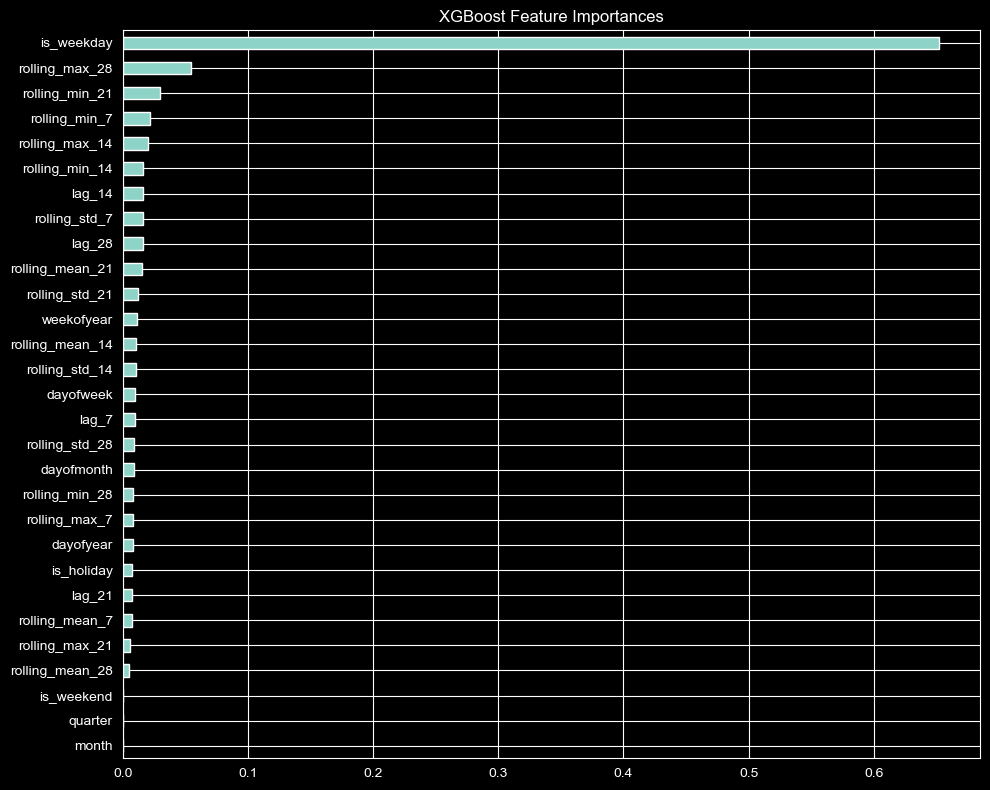

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

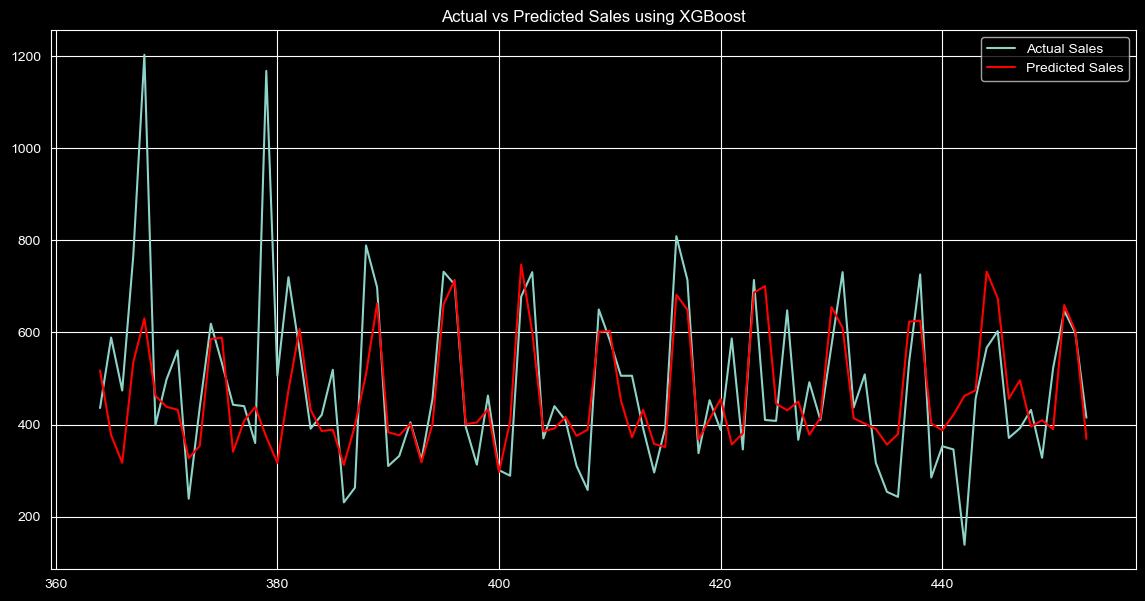

In [48]:
# Ist- vs. Prognosewerte plotten
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Sales')
plt.plot(y_test.index, y_pred_xgb, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales using XGBoost')
plt.legend()
plt.show()

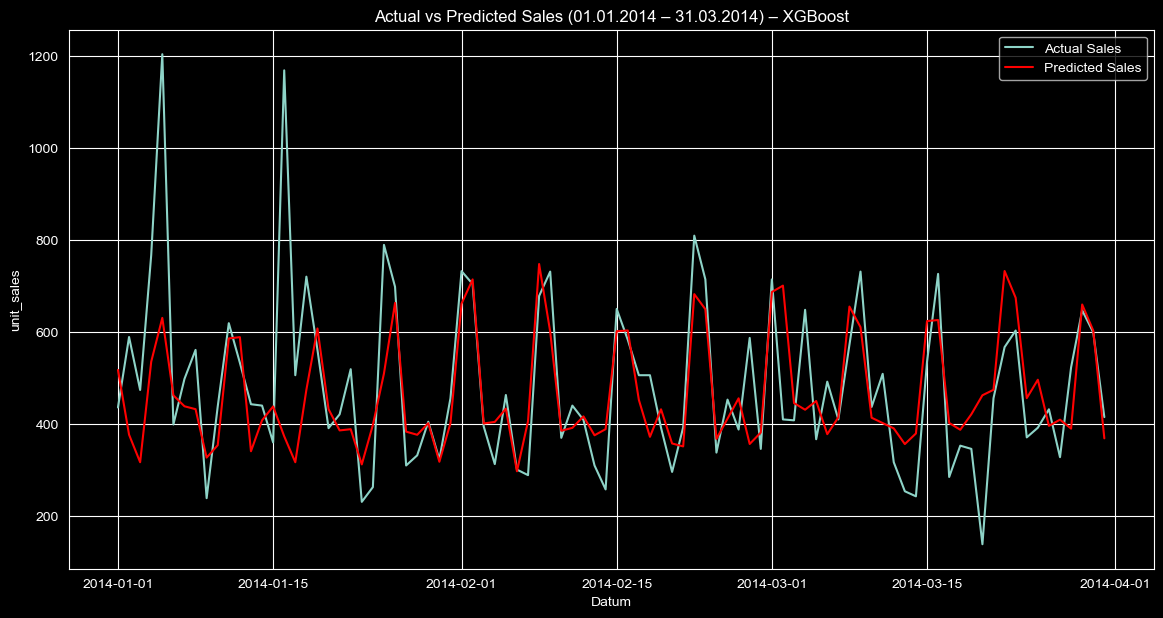

In [49]:
test_filter = (
    (time_series_ALL_features["date"] >= "2014-01-01") &
    (time_series_ALL_features["date"] <= "2014-03-31")
)

test_dates = time_series_ALL_features.loc[test_filter, "date"]

# Datum aus dem Original-DataFrame holen
test_dates = time_series_ALL_features.loc[test_filter, "date"]

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test.values, label='Actual Sales')
plt.plot(test_dates, y_pred_xgb, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales (01.01.2014 – 31.03.2014) – XGBoost')
plt.xlabel("Datum")
plt.ylabel("unit_sales")
plt.legend()
plt.show()

- Du simulierst: „Wenn ich jeden Tag eine 1-Schritt-Vorhersage mache und dabei die echten Vortageswerte kenne" – das ist realistisch und methodisch sauber.

<=> Schema von echten Multi-Step Forecast, dass in der Praxis realistischer wäre:
- Training: alle Daten bis 31.12.2013
- ↓
- Vorhersage Tag 1 (01.01.2014) → mit echten Lag-Features aus 2013
- ↓
- Vorhersage Tag 2 (02.01.2014) → lag_7 noch echt, aber lag_1 = vorhergesagter Wert
- ↓
- ...
- ↓
- Vorhersage Tag 90 (31.03.2014) → fast alle Lag-Features = vorhergesagte Werte
- ↓
- Vergleich mit echten Testdaten

# Linear Regression
## Daten vorbereiten

In [50]:
# (1) NaNs entfernen (damit kann linear Regression nicht umgehen)
time_series_added_features_reduced_colinearity_NAsDropped = time_series_added_features_reduced_colinearity.dropna()

# (2) Splitten => Chronologisch splitten. Nicht wie in "normalen" ML randomisiert in z.B. 20% Test und 80% Train Data splitten!!
# (2a) Sortieren (sicherheitshalber)
time_series_added_features_reduced_colinearity_NAsDropped = time_series_added_features_reduced_colinearity_NAsDropped.sort_values("date")

# (2b) Zielvariable und Features definieren
y = time_series_added_features_reduced_colinearity_NAsDropped['unit_sales']

# (2c) Features definieren
X = time_series_added_features_reduced_colinearity_NAsDropped.drop(columns=['unit_sales', 'date'])

# (2d) Zeitraum-basierter Split
train_filter = time_series_added_features_reduced_colinearity_NAsDropped["date"] < "2014-01-01"
test_filter  = (time_series_added_features_reduced_colinearity_NAsDropped["date"] >= "2014-01-01") & \
               (time_series_added_features_reduced_colinearity_NAsDropped["date"] <= "2014-03-31")        # => Das "\" sagt dem Interpreter: „Die nächste Zeile gehört noch zu diesem Ausdruck."

X_train = X[train_filter]
y_train = y[train_filter]

X_test = X[test_filter]
y_test = y[test_filter]


## Model definition, training and predictions

In [51]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

## Evaluation

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred_lr)
mse  = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MAE:  {mae:.2f}")
print(f"Linear Regression MSE:  {mse:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")
print(f"Linear Regression R²:   {r2:.4f}")

Linear Regression MAE:  92.72
Linear Regression MSE:  18813.96
Linear Regression RMSE: 137.16
Linear Regression R²:   0.4411


## Feature Importance

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

# Koeffizienten nach Skalierung (Koeffizienten (nach Standardisierung) sind das Maß für Feature Importance bei Linear Regression)
import pandas as pd
coefs = pipeline_lr.named_steps["model"].coef_
importance_lr = pd.DataFrame({
    "Feature":     X_train.columns,
    "Coefficient": coefs
}).sort_values("Coefficient", key=abs, ascending=False)

print(importance_lr)

            Feature  Coefficient
4        is_weekend    78.351970
6            lag_14    19.910941
11   rolling_max_14    15.412712
7            lag_21    14.557416
8            lag_28    14.351827
2        dayofmonth   -13.901131
9   rolling_mean_21   -12.712469
12   rolling_min_21    10.781252
10   rolling_std_14    -9.159850
0        is_holiday     8.875619
5             lag_7     8.088798
1         dayofweek    -6.639833
3             month     2.743091


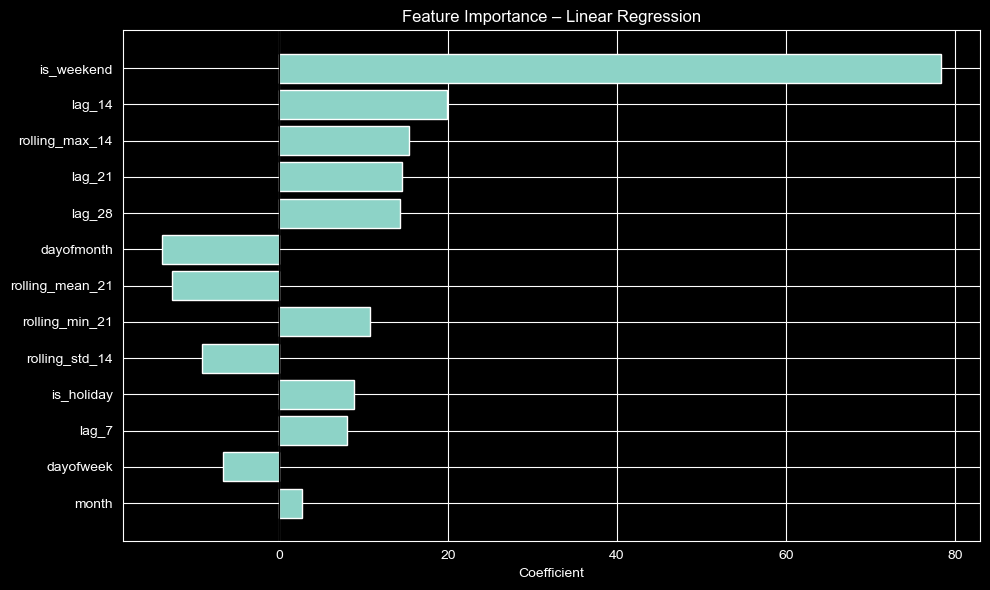

In [54]:
import matplotlib.pyplot as plt

# Sortieren nach Absolutwert (größter Einfluss oben)
importance_sorted = importance_lr.sort_values("Coefficient", key=abs, ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_sorted["Feature"], importance_sorted["Coefficient"])
plt.axvline(x=0, color="black", linewidth=0.8)  # Nulllinie
plt.xlabel("Coefficient")
plt.title("Feature Importance – Linear Regression")
plt.tight_layout()
plt.show()

- Ein negativer Koeffizient bedeutet: je größer der Featurewert, desto kleiner die vorhergesagten unit_sales.

# Ranodom Forest
## Daten vorbereiten

In [55]:
# (1) NaNs entfernen (damit kann Random Forest nicht umgehen); Allerdings kann Random Forest genau wie XGBoost mit Colinearity umgehen!
time_series_ALL_features_NAsDropped = time_series_ALL_features.dropna()

# (2) Splitten => Chronologisch splitten. Nicht wie in "normalen" ML randomisiert in z.B. 20% Test und 80% Train Data splitten!!
# (2a) Sortieren (sicherheitshalber)
time_series_ALL_features_NAsDropped = time_series_ALL_features_NAsDropped.sort_values("date")

# (2b) Zielvariable und Features definieren
y = time_series_ALL_features_NAsDropped['unit_sales']

# (2c) Features definieren
X = time_series_ALL_features_NAsDropped.drop(columns=['unit_sales', 'date'])

# (2d) Zeitraum-basierter Split
train_filter = time_series_ALL_features_NAsDropped["date"] < "2014-01-01"
test_filter  = (time_series_ALL_features_NAsDropped["date"] >= "2014-01-01") & \
               (time_series_ALL_features_NAsDropped["date"] <= "2014-03-31")        # => Das "\" sagt dem Interpreter: „Die nächste Zeile gehört noch zu diesem Ausdruck."

X_train = X[train_filter]
y_train = y[train_filter]

X_test = X[test_filter]
y_test = y[test_filter]

## Model definition, training and predictions

In [56]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=1000,   # Anzahl Bäume
    max_depth=5,        # Tiefe der Bäume
    random_state=42
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

## Evaluation

In [57]:
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print(f"Linear Regression MAE:  {mae:.2f}")
print(f"Linear Regression MSE:  {mse:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")
print(f"Linear Regression R²:   {r2:.4f}")

Linear Regression MAE:  93.25
Linear Regression MSE:  20157.81
Linear Regression RMSE: 141.98
Linear Regression R²:   0.4012


## Feature Importance

In [58]:
importance_rf = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": model_rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_rf)

            Feature  Importance
2         dayofweek    0.224458
8        is_weekend    0.224172
0        is_weekday    0.211619
10           lag_14    0.040658
3        dayofmonth    0.032967
12           lag_28    0.029691
11           lag_21    0.026418
25    rolling_min_7    0.021963
17    rolling_std_7    0.017936
9             lag_7    0.016081
14  rolling_mean_14    0.013140
20   rolling_std_28    0.012353
19   rolling_std_21    0.012173
4         dayofyear    0.012121
18   rolling_std_14    0.011331
16  rolling_mean_28    0.010537
15  rolling_mean_21    0.010176
13   rolling_mean_7    0.009790
28   rolling_min_28    0.009027
26   rolling_min_14    0.008806
22   rolling_max_14    0.007579
5        weekofyear    0.006859
24   rolling_max_28    0.006591
27   rolling_min_21    0.006063
21    rolling_max_7    0.005527
6             month    0.004916
23   rolling_max_21    0.003621
1        is_holiday    0.002586
7           quarter    0.000840


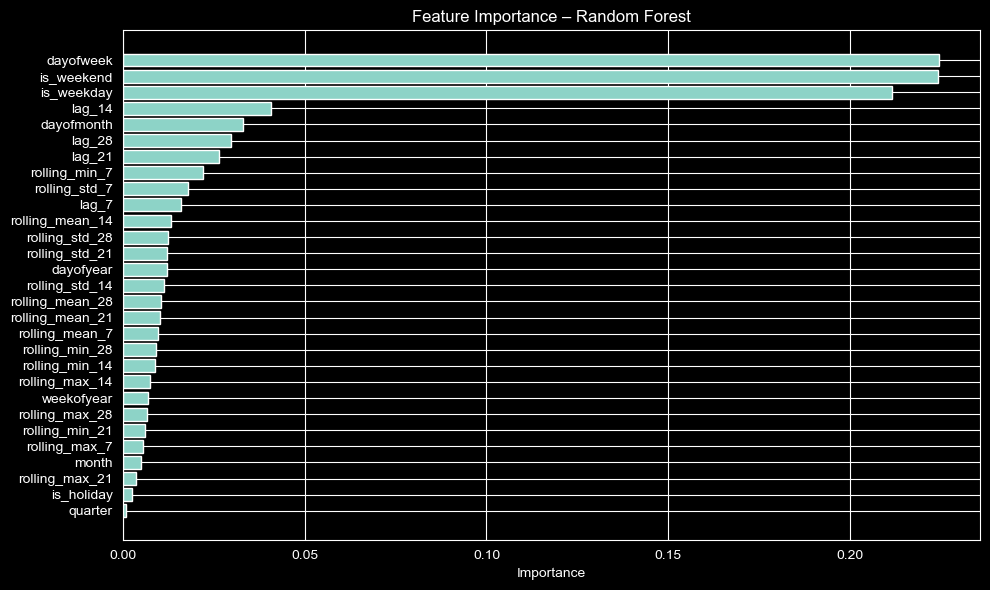

In [59]:
importance_sorted = importance_rf.sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_sorted["Feature"], importance_sorted["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance – Random Forest")
plt.tight_layout()
plt.show()